In [2]:
from google.colab import files
uploaded = files.upload()
print(uploaded)


Saving us_sentiment_analysis.csv to us_sentiment_analysis.csv
{'us_sentiment_analysis.csv': b'tweet_id,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone\n569682010270101504,American,,zsalim03,,0,@AmericanAir In car gng to DFW. Pulled over 1hr ago - very icy roads. On-hold with AA since 1hr. Can\'t reach arpt for AA2450. Wat 2 do?,,2015-02-22 18:15:50 -0800,Texas,Central Time (US & Canada)\n569608307184242688,American,,sa_craig,,0,"@AmericanAir after all, the plane didn\xe2\x80\x99t land in identical or worse) conditions at GRK according to METARs.",,2015-02-22 13:22:57 -0800,"College Station, TX",Central Time (US & Canada)\n567879304593408001,Southwest,,DanaChristos,,1,@SouthwestAir can\'t believe how many paying customers you left high and dry with no reason for flight Cancelled Flightlations Monday out of BDL! Wow.,,2015-02-17 18:52:31 -0800,CT,Eastern Time (US & Canada)\n569757651539660801,US Airways,,ro

In [12]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import os

sns.set_style("whitegrid")

In [13]:
file_path = "us_sentiment_analysis.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError("CSV file not found.")

df = pd.read_csv(file_path)

print("\nDataset Loaded Successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns)
print(df.head())



Dataset Loaded Successfully!
Shape: (3660, 11)
Columns: Index(['tweet_id', 'airline', 'airline_sentiment_gold', 'name',
       'negativereason_gold', 'retweet_count', 'text', 'tweet_coord',
       'tweet_created', 'tweet_location', 'user_timezone'],
      dtype='object')
             tweet_id     airline airline_sentiment_gold          name  \
0  569682010270101504    American                    NaN      zsalim03   
1  569608307184242688    American                    NaN      sa_craig   
2  567879304593408001   Southwest                    NaN  DanaChristos   
3  569757651539660801  US Airways                    NaN      rossj987   
4  569900705852608513    American                    NaN    tranpham18   

  negativereason_gold  retweet_count  \
0                 NaN              0   
1                 NaN              0   
2                 NaN              1   
3                 NaN              0   
4                 NaN              0   

                                         

In [15]:
possible_text_cols = ["text", "tweet", "content", "message"]

text_column = None
for col in df.columns:
    if col.lower() in possible_text_cols:
        text_column = col
        break

if text_column is None:
    text_column = df.columns[0]

print("\nUsing text column:", text_column)



Using text column: text


In [16]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)



Missing Values:
tweet_id                     0
airline                      0
airline_sentiment_gold    3651
name                         0
negativereason_gold       3652
retweet_count                0
text                         0
tweet_coord               3417
tweet_created                0
tweet_location            1183
user_timezone             1243
dtype: int64

Data Types:
tweet_id                   int64
airline                   object
airline_sentiment_gold    object
name                      object
negativereason_gold       object
retweet_count              int64
text                      object
tweet_coord               object
tweet_created             object
tweet_location            object
user_timezone             object
dtype: object


In [17]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(f"[{string.punctuation}]", "", text)
    text = text.strip()
    return text

df["clean_text"] = df[text_column].apply(clean_text)

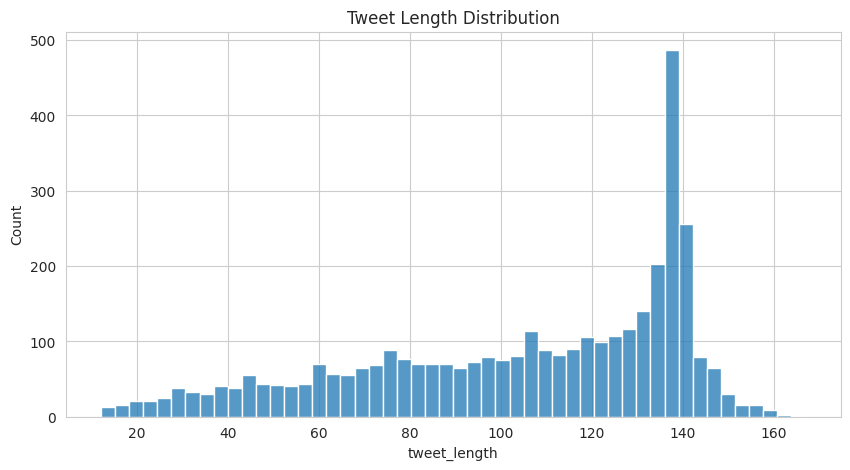

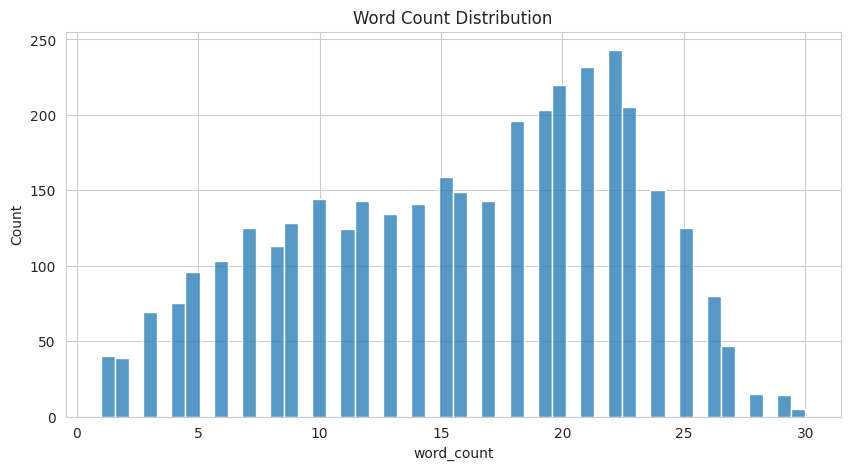

In [18]:
df["tweet_length"] = df[text_column].astype(str).apply(len)
df["word_count"] = df["clean_text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
sns.histplot(df["tweet_length"], bins=50)
plt.title("Tweet Length Distribution")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df["word_count"], bins=50)
plt.title("Word Count Distribution")
plt.show()


In [19]:
possible_label_cols = ["sentiment", "label", "airline_sentiment", "target"]

label_column = None
for col in df.columns:
    if col.lower() in possible_label_cols:
        label_column = col
        break

if label_column:
    plt.figure(figsize=(8,5))
    sns.countplot(x=df[label_column])
    plt.title("Sentiment Distribution")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("\nNo sentiment column found.")


No sentiment column found.


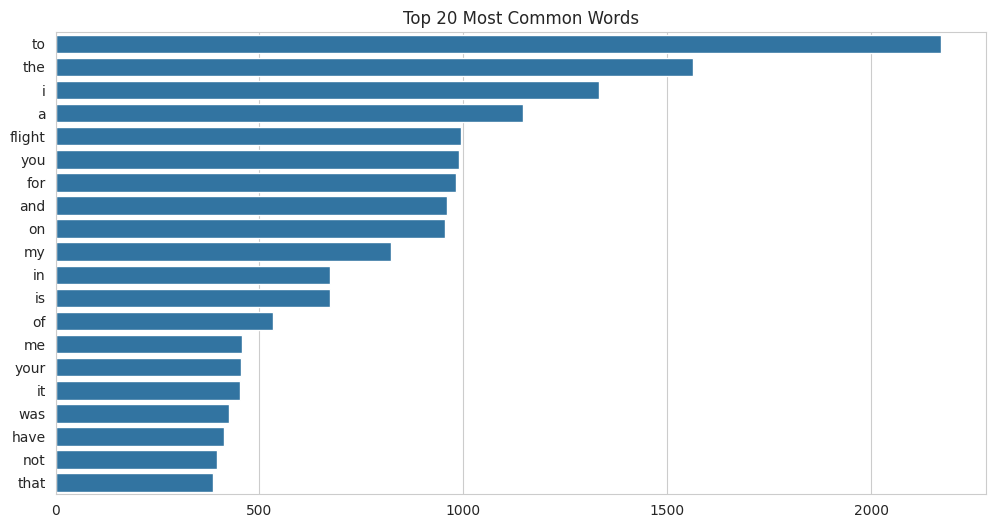

In [20]:
all_words = " ".join(df["clean_text"]).split()
word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(12,6))
sns.barplot(x=counts, y=words)
plt.title("Top 20 Most Common Words")
plt.show()


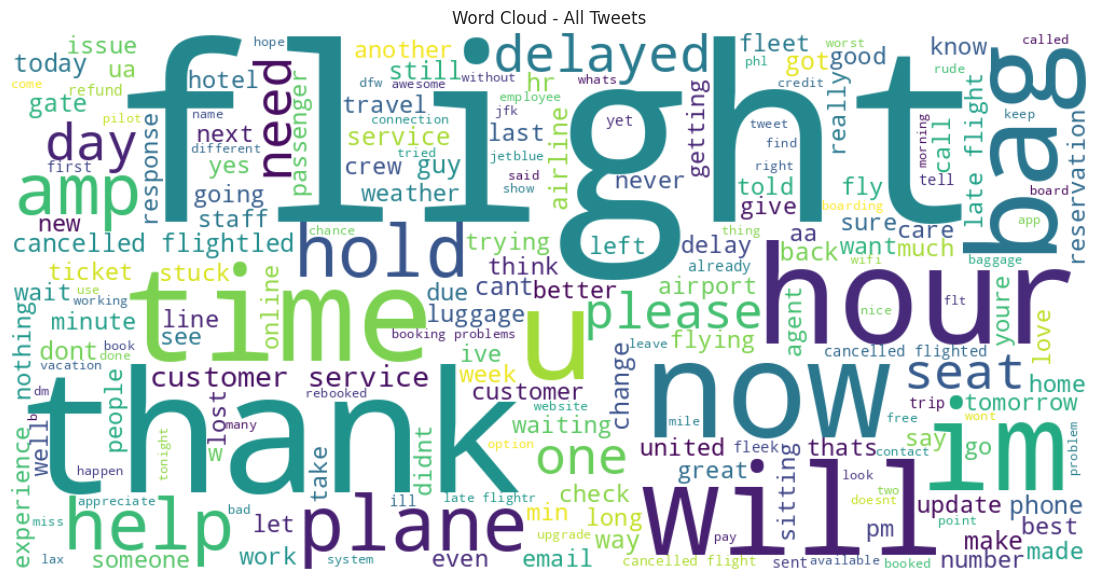

In [21]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(" ".join(df["clean_text"]))

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - All Tweets")
plt.show()


In [22]:
if label_column:
    sentiments = df[label_column].unique()

    for sentiment in sentiments:
        subset = df[df[label_column] == sentiment]
        text_data = " ".join(subset["clean_text"])

        wordcloud = WordCloud(
            width=1000,
            height=500,
            background_color='white'
        ).generate(text_data)

        plt.figure(figsize=(15,7))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")
        plt.title(f"Word Cloud - {sentiment}")
        plt.show()


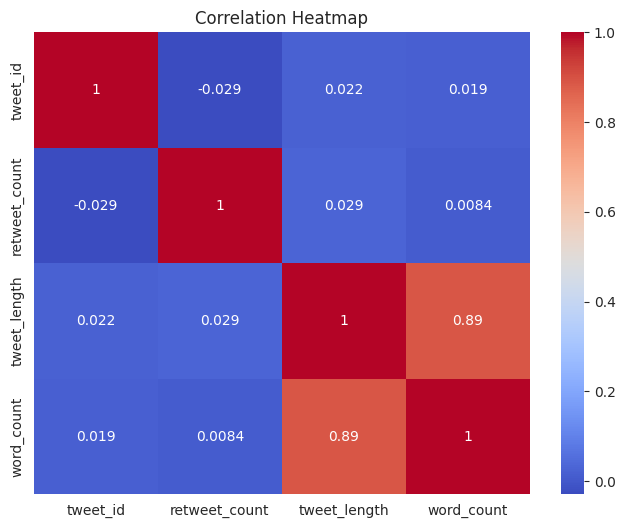


EDA & Visualization Completed Successfully!


In [23]:
numeric_cols = df.select_dtypes(include=np.number)

if not numeric_cols.empty:
    plt.figure(figsize=(8,6))
    sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()


print("\nEDA & Visualization Completed Successfully!")